[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rafelsalgueiro/GallegoSalgueiroVera/blob/main/Entornos_Complejos/deep_q_learning.ipynb)

# Entrenamiento de Deep Q-Learning en Flappy Bird

Este notebook contiene el proceso de experimentación y entrenamiento de un agente DQN para resolver el entorno FlappyBird-v0. El juego que modela este entorno consiste en un personaje (un pájaro) que avanza con velocidad horizontal constante y mediante saltos y esperas tiene que desplazarse verticalmente para sortear obstáculos (tuberías). Una explicación más detallada de este entorno se encuentra en el notebook `flappy_bird.ipynb`.

```
Authors: Gallego, Salgueiro y Vera.
Date: 2026/02/16
```

## 1. Preparación del entorno 

En esta sección configuramos el entorno de ejecución, instalamos las dependencias necesarias y aseguramos la reproducibilidad de los experimentos.

In [1]:
!git clone https://github.com/rafelsalgueiro/GallegoSalgueiroVera.git

In [2]:
%pip install -q gymnasium flappy-bird-gymnasium torch numpy matplotlib seaborn pygame tqdm pandas scipy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
!cd GallegoSalgueiroVera/Entornos_Complejos && pwd

Después de la instalación, realizamos la importación de librerías y configuración.

In [3]:
import os
import pickle
import sys
from collections import deque

import torch
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import mannwhitneyu
from tqdm import tqdm

project_root = os.path.abspath('GallegoSalgueiroVera/Entornos_Complejos')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.envs.flappy_bird import make_flappy_bird_env
from src.agents.td_agents_dqn import DQNAgent, DQNReplayBuffer
from src.plotting.plotting import plot_robust_learning_curves

print("Módulos importados con éxito.")

Módulos importados con éxito.


Continuamos con la creación de directorios para almacenar los modelos y resultados y la configuración del dispositivo.

In [4]:
MODELS_DIR = os.path.join(project_root, "models")
RESULTS_DIR = os.path.join(project_root, "results")

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo configurado para entrenamiento: {DEVICE.upper()}")

Dispositivo configurado para entrenamiento: CUDA


Finalmente, aseguramos la reproducibilidad de los experimentos definiendo una semilla aleatoria.

In [5]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Semilla global fijada en: {seed}")

# Fijamos la semilla inicial
GLOBAL_SEED = 3141592
set_seed(GLOBAL_SEED)

Semilla global fijada en: 3141592


## 2. Diseño experimental y bucle de entrenamiento

En primer lugar, definimos el método que va a dar forma a todos los entrenamientos que hagamos. Mientras se ejecuta el bucle usamos la librería `tqdm` para mostrar una barra de progreso que, además de mostrarnos los episodios evaluados, nos muestra la mejor puntuación real media obtenida en una ventana de 30 episodios.


In [6]:
def train_dqn(env, agent, buffer, num_episodes, batch_size, min_memory, max_steps, strat_name, seed, models_dir, break_inform=1):
    """
    Ejecuta el bucle de entrenamiento estándar de DQN con Model Checkpointing.
    El checkpointing se basa en la puntuación real del juego (tuberías cruzadas),
    no en la recompensa interna (que puede incluir shaping).
    """
    n_actions = env.action_space.n

    history = {
        'rewards': [], 'lengths': [], 'losses': [], 'max_q_values': []
    }
    
    window_size = 30
    recent_scores = deque(maxlen=window_size)
    
    best_window_score = -float('inf')
    best_episode = 0
    best_model_path = os.path.join(models_dir, f"best_{strat_name}_seed_{seed}.pth")

    milestone = num_episodes // break_inform

    pbar = tqdm(range(num_episodes), desc=f"Entrenando {strat_name} (Seed {seed})", leave=False)
    
    for ep in pbar:
        state, _ = env.reset(seed=seed+ep)
        done = False
        ep_reward = 0
        ep_length = 0
        ep_losses = []
        ep_max_qs = []
        ep_score = 0
        
        while not done:
            # Forward pass para obtener Q-values, acción y max-Q
            q_values = agent.get_q_value(state)
            ep_max_qs.append(np.max(q_values))
            
            if random.random() < agent.epsilon:
                action = random.randint(0, n_actions - 1)
            else:
                max_q = np.max(q_values)
                best_actions = np.where(q_values == max_q)[0]
                action = random.choice(best_actions)
            
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            ep_score = info.get('score', ep_score)
            
            buffer.add(state, action, reward, next_state, done)

            if len(buffer) >= min_memory:
                states_b, actions_b, rewards_b, next_states_b, dones_b = buffer.sample(batch_size)
                loss = agent.train_step(states_b, actions_b, rewards_b, next_states_b, dones_b)
                ep_losses.append(loss)
                
            state = next_state
            ep_reward += reward
            ep_length += 1

            if ep_length >= max_steps:
                done = True
            
        agent.decay_epsilon()
        
        ep_mean_q = np.mean(ep_max_qs) if ep_max_qs else 0.0
        
        history['rewards'].append(ep_reward)
        history['lengths'].append(ep_length)
        history['losses'].append(np.mean(ep_losses) if ep_losses else 0.0)
        history['max_q_values'].append(ep_mean_q)
        
        # Checkpointing
        if len(buffer) >= min_memory:
            recent_scores.append(ep_score)
            
            if len(recent_scores) == window_size:
                current_mean = np.mean(recent_scores)
                
                if current_mean > best_window_score:
                    best_window_score = current_mean
                    best_episode = ep
                    agent.save_weights(best_model_path)
                    
                    pbar.set_postfix({
                        "Récord": f"{best_window_score:.2f}",
                        "Ep": best_episode
                    })

        # Reporte
        if milestone > 0 and ep > 0 and ep % milestone == 0:
            porcentaje = int((ep / num_episodes) * 100)
            if best_window_score != -float('inf'):
                pbar.write(f"[{porcentaje}%] Progreso general | Mejor media actual: {best_window_score:.2f} tuberías (episodio {best_episode})")
            else:
                pbar.write(f"[{porcentaje}%] Progreso general | (Llenando memoria, sin récord aún)")
    
    # Auto-restauración del mejor modelo
    if os.path.exists(best_model_path):
        agent.load_weights(best_model_path)
        
    return history

Para determinar la estrategia de aprendizaje más robusta y eficiente, estableceremos un marco de evaluación justo aislando tres componentes críticos: el uso de una **Red Objetivo (Target Network)** para la estabilidad del aprendizaje, la aplicación de **Reward Shaping** para guiar la exploración temprana del agente, y el uso de **Double DQN** para reducir la sobreestimación de valores Q.

El *Reward Shaping* se controla mediante el parámetro $\alpha$, que otorga una bonificación proporcional a la cercanía del agente al centro del hueco entre las tuberías. Evaluaremos seis configuraciones distintas. Para garantizar la validez estadística y mitigar la alta varianza inherente al Aprendizaje por Refuerzo Profundo, cada estrategia se entrenará desde cero utilizando **5 semillas aleatorias diferentes** durante **2000 episodios**.

### Configuraciones a Evaluar

| ID | Nombre de la Estrategia | Target Network | Double DQN | Reward Shaping ($\alpha$) | Descripción y Objetivo del Experimento |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **A** | Vanilla DQN (Sin Target) | No | No | 0.0 | **Línea base pura:** DQN original propuesto en 2013. Se espera alta inestabilidad y sobreestimación catastrófica. |
| **B** | DQN Estándar | Sí | No | 0.0 | **Línea base moderna:** DQN con red objetivo. Solo aprende de las recompensas nativas (sobrevivir y cruzar). |
| **C** | DQN + Shaping ligero | Sí | No | 0.05 | **Heurística anecdótica:** Bonificación menor a la recompensa por supervivencia. |
| **D** | DQN + Shaping Moderado | Sí | No | 0.25 | **Heurística de apoyo:** Bonificación suave por centrarse. |
| **E** | DQN + Shaping Agresivo | Sí | No | 0.50 | **Heurística estricta:** Evalúa el riesgo de *Reward Misalignment*. |
| **F** | Double DQN | Sí | Sí | 0.0 | **Reducción de sobreestimación:** Desacopla selección y evaluación de acciones para obtener estimaciones Q más fieles. |

Todos los demás hiperparámetros (arquitectura de la red, capacidad de memoria, decaimiento de exploración, tasa de aprendizaje, etc.) se mantendrán constantes entre los seis grupos.

In [7]:
NUM_EPISODES = 2000
NUM_SEEDS = 5
SEEDS = [GLOBAL_SEED, GLOBAL_SEED+1, GLOBAL_SEED+2, GLOBAL_SEED+3, GLOBAL_SEED+4]
# Parámetros del Replay Buffer
BUFFER_CAPACITY = 10000
MIN_MEMORY = 1000
BATCH_SIZE = 64

# Parámetros de la Red Neuronal y Optimizador
HIDDEN_DIM = 128
LEARNING_RATE = 1e-3
GAMMA = 0.99
GRAD_CLIP = 1.0

# Parámetros de Exploración (Epsilon-Greedy)
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.996

# Parámetros de la Red Objetivo (cuando se usa)
TARGET_UPDATE_FREQ = 500

MAX_STEPS_PER_EPISODE = 2000 

experiments_config = {
    "A_Vanilla_DQN": {
        "alpha": 0.0,
        "use_target_network": False,
        "double_dqn": False
    },
    "B_DQN_Standard": {
        "alpha": 0.0,
        "use_target_network": True,
        "double_dqn": False
    },
    "C_DQN_Shaping_Lev": {
        "alpha": 0.05,
        "use_target_network": True,
        "double_dqn": False
    },
    "D_DQN_Shaping_Mod": {
        "alpha": 0.25,
        "use_target_network": True,
        "double_dqn": False
    },
    "E_DQN_Shaping_Agr": {
        "alpha": 0.50,
        "use_target_network": True,
        "double_dqn": False
    },
    "F_Double_DQN": {
        "alpha": 0.0,
        "use_target_network": True,
        "double_dqn": True
    }
}

print(f"Configurados {len(experiments_config)} experimentos. "
      f"Entrenamientos totales a ejecutar: {len(experiments_config) * NUM_SEEDS} "
      f"({NUM_EPISODES} episodios por entrenamiento).")

Configurados 6 experimentos. Entrenamientos totales a ejecutar: 30 (2000 episodios por entrenamiento).


## 3. Entrenamiento exploratorio y evaluación

En esta fase, ejecutaremos la batería de experimentos diseñada. Para garantizar una comparativa rigurosa, cada estrategia será entrenada desde cero a través de múltiples semillas aleatorias, lo que nos permitirá evaluar tanto su rendimiento promedio como su estabilidad (varianza).

El proceso de evaluación consta de dos pilares para cada semilla:
1. **Fase de Entrenamiento (Tendencia y Potencial):** Entrenaremos al agente durante 2000 episodios, registrando su recompensa acumulada, longitud del episodio, pérdida (Loss) y Valores Q. Esto nos mostrará la curva de aprendizaje y si el agente tiene una tendencia de mejora continua o si se estanca prematuramente.
2. **Fase de Evaluación Greedy (Rendimiento Real):** Inmediatamente después del entrenamiento, congelaremos el aprendizaje del agente y anularemos su tasa de exploración ($\epsilon = 0.0$). Someteremos a su mejor versión (a la que logró mejor puntuación real en una ventana de 30 episodios durante el entrenamiento) a **100 episodios de prueba** donde actuará de forma totalmente determinista (explotación pura). En esta fase ignoraremos las recompensas modificadas (*shaping*) y mediremos únicamente la **puntuación real del juego** (número de tuberías cruzadas exitosamente).

Agregar los resultados a lo largo de todas las semillas nos proporcionará una distribución de datos pura sobre la que calcularemos la media, mediana y desviación típica, y que visualizaremos posteriormente mediante diagramas de caja (*boxplots*).

In [8]:
training_curves = {
    strat: {'rewards': [], 'lengths': [], 'losses': [], 'max_qs': []} 
    for strat in experiments_config.keys()
}

evaluation_scores = {strat: [] for strat in experiments_config.keys()}

NUM_EVAL_EPISODES = 100

# Entorno para evaluar
eval_env = make_flappy_bird_env(alpha=0.0)

print("Iniciando experimentos\n")

for strat_name, strat_params in experiments_config.items():
    print(f"{'='*80}\nEstrategia: {strat_name} | Alpha: {strat_params['alpha']} | Target: {strat_params['use_target_network']} | Double: {strat_params['double_dqn']}\n{'='*80}")
    
    strat_alpha = strat_params['alpha']
    use_target = strat_params['use_target_network']
    use_double = strat_params['double_dqn']
    
    for seed_idx, seed in enumerate(SEEDS):
        print(f"\nSemilla {seed_idx + 1}/{NUM_SEEDS} ({seed})")
        set_seed(seed)
        
        # Entorno y agente
        env = make_flappy_bird_env(alpha=strat_alpha)
        buffer = DQNReplayBuffer(BUFFER_CAPACITY, env.observation_space.shape[0], seed=seed)
        agent = DQNAgent(
            env=env, alpha=LEARNING_RATE, gamma=GAMMA, 
            epsilon_start=EPSILON_START, epsilon_min=EPSILON_MIN, epsilon_decay=EPSILON_DECAY, 
            hidden_dim=HIDDEN_DIM, use_target_network=use_target, target_update_freq=TARGET_UPDATE_FREQ, 
            double_dqn=use_double, device=DEVICE
        )
        
        # Fase de Entrenamiento
        history = train_dqn(
            env, agent, buffer, NUM_EPISODES, BATCH_SIZE, MIN_MEMORY, MAX_STEPS_PER_EPISODE,
            strat_name=strat_name, seed=seed, models_dir=MODELS_DIR
        )

        training_curves[strat_name]['rewards'].append(history['rewards'])
        training_curves[strat_name]['lengths'].append(history['lengths'])
        training_curves[strat_name]['losses'].append(history['losses'])
        training_curves[strat_name]['max_qs'].append(history['max_q_values'])
        
        # Fase de evaluación greedy (con el mejor modelo encontrado)
        best_model_path = os.path.join(MODELS_DIR, f"best_{strat_name}_seed_{seed}.pth")
        if os.path.exists(best_model_path):
            agent.load_weights(best_model_path)
        
        agent.epsilon = 0.0
        agent.env = eval_env
        seed_eval_scores = []
        
        for i in range(NUM_EVAL_EPISODES):
            state, _ = eval_env.reset(seed=GLOBAL_SEED + i)
            done = False
            score = 0
            step_count = 0
            while not done and step_count < MAX_STEPS_PER_EPISODE:
                action = agent.get_action(state)
                state, reward, terminated, truncated, info = eval_env.step(action)
                done = terminated or truncated
                score = info.get('score', score)
                step_count += 1
            seed_eval_scores.append(score)
            
        evaluation_scores[strat_name].extend(seed_eval_scores)
        print(f"   Evaluación finalizada. Score Promedio: {np.mean(seed_eval_scores):.2f} tuberías.")

    # Convertir las listas de historiales a matrices NumPy (num_seeds, num_episodes)
    for metric in training_curves[strat_name]:
        training_curves[strat_name][metric] = np.array(training_curves[strat_name][metric])

with open(os.path.join(RESULTS_DIR, 'training_curves.pkl'), 'wb') as f:
    pickle.dump(training_curves, f)
with open(os.path.join(RESULTS_DIR, 'evaluation_scores.pkl'), 'wb') as f:
    pickle.dump(evaluation_scores, f)

print("\nTodos los experimentos han finalizado y los datos han sido guardados en 'results/'.")

Iniciando experimentos

Estrategia: A_Vanilla_DQN | Alpha: 0.0 | Target: False | Double: False

Semilla 1/5 (3141592)
Semilla global fijada en: 3141592


   Evaluación finalizada. Score Promedio: 1.98 tuberías.

Semilla 2/5 (3141593)
Semilla global fijada en: 3141593


   Evaluación finalizada. Score Promedio: 2.17 tuberías.

Semilla 3/5 (3141594)
Semilla global fijada en: 3141594


   Evaluación finalizada. Score Promedio: 0.07 tuberías.

Semilla 4/5 (3141595)
Semilla global fijada en: 3141595


   Evaluación finalizada. Score Promedio: 1.67 tuberías.

Semilla 5/5 (3141596)
Semilla global fijada en: 3141596


...

   Evaluación finalizada. Score Promedio: 2.71 tuberías.

Semilla 2/5 (3141593)
Semilla global fijada en: 3141593


   Evaluación finalizada. Score Promedio: 2.67 tuberías.

Semilla 3/5 (3141594)
Semilla global fijada en: 3141594


   Evaluación finalizada. Score Promedio: 3.53 tuberías.

Semilla 4/5 (3141595)
Semilla global fijada en: 3141595


   Evaluación finalizada. Score Promedio: 7.11 tuberías.

Semilla 5/5 (3141596)
Semilla global fijada en: 3141596


   Evaluación finalizada. Score Promedio: 1.69 tuberías.

Todos los experimentos han finalizado y los datos han sido guardados en 'results/'.


Generando Curvas de Aprendizaje...


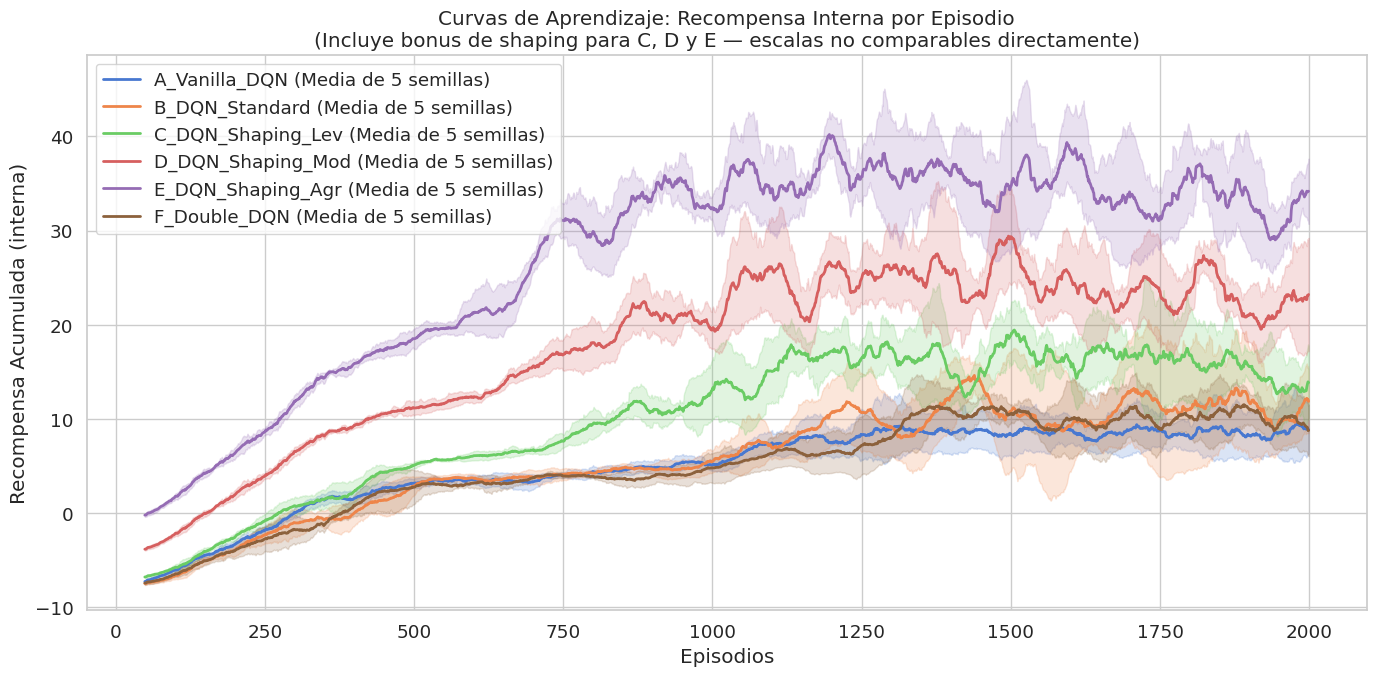

Generando Evolución de Valores Q...


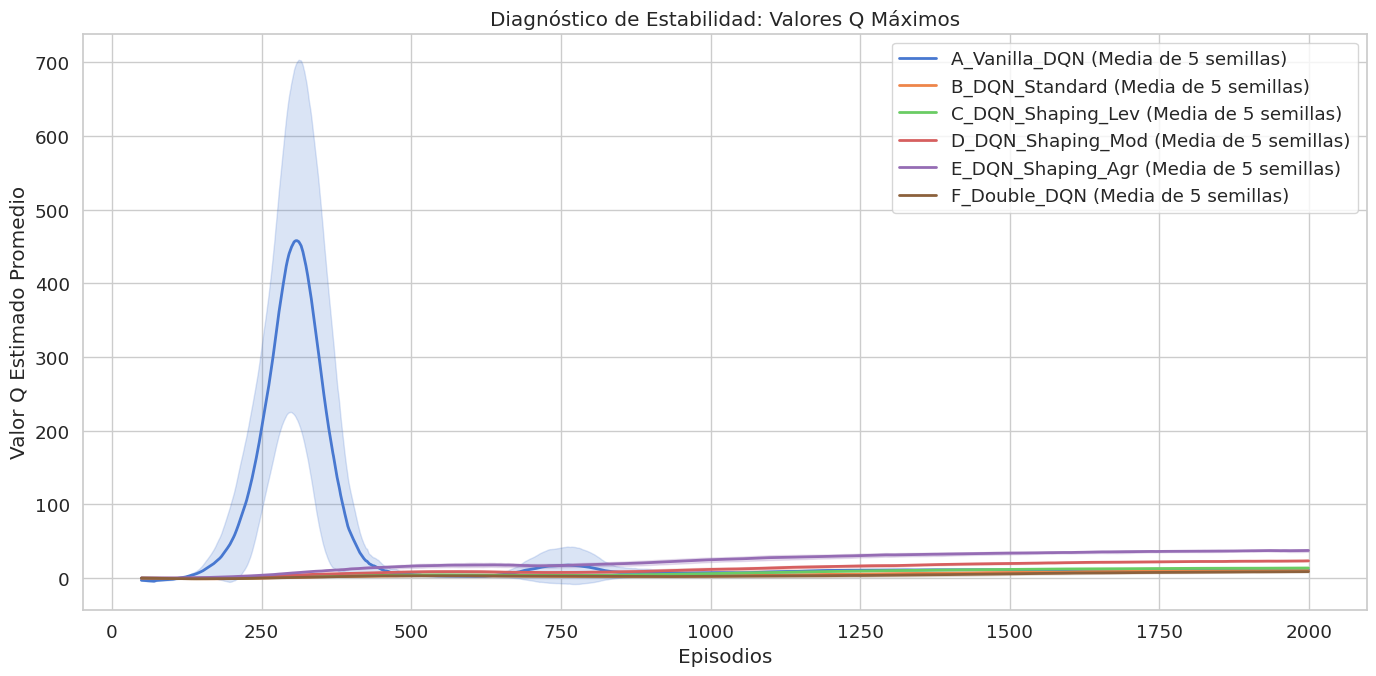

Generando Evolución de la Pérdida...


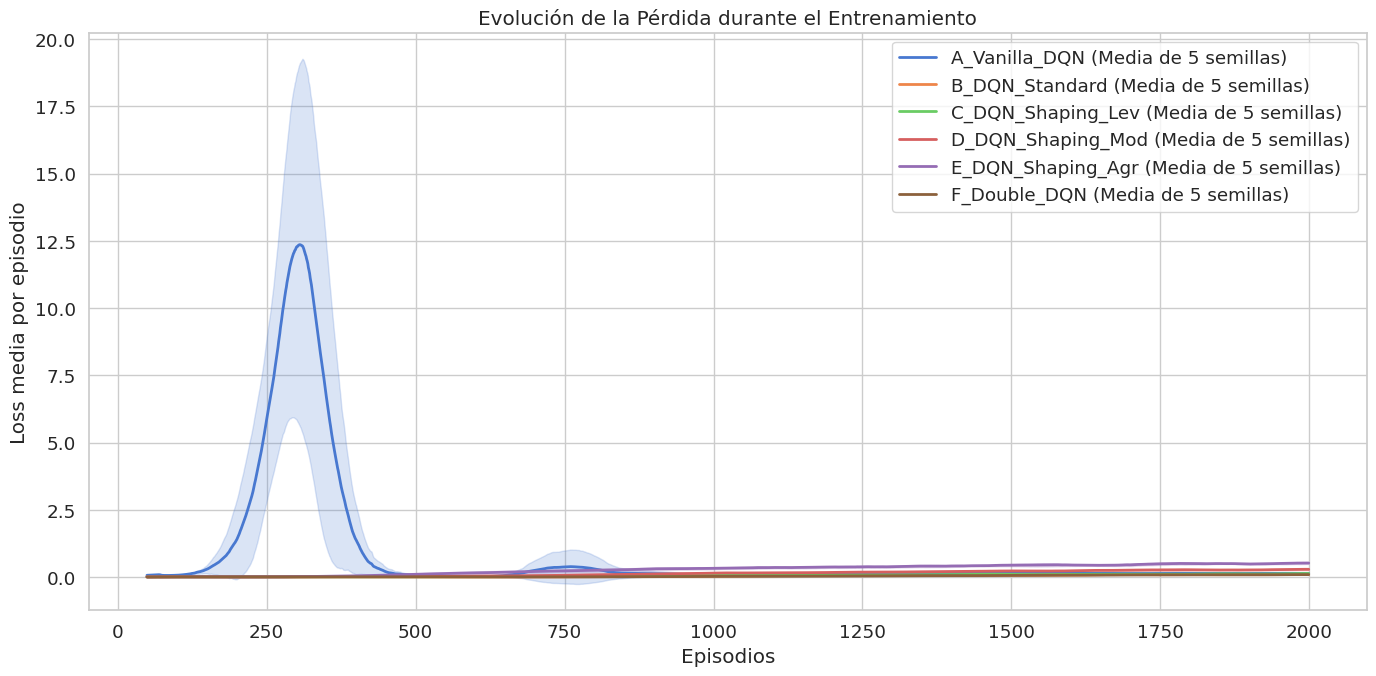

Generando Longitud de Episodios...


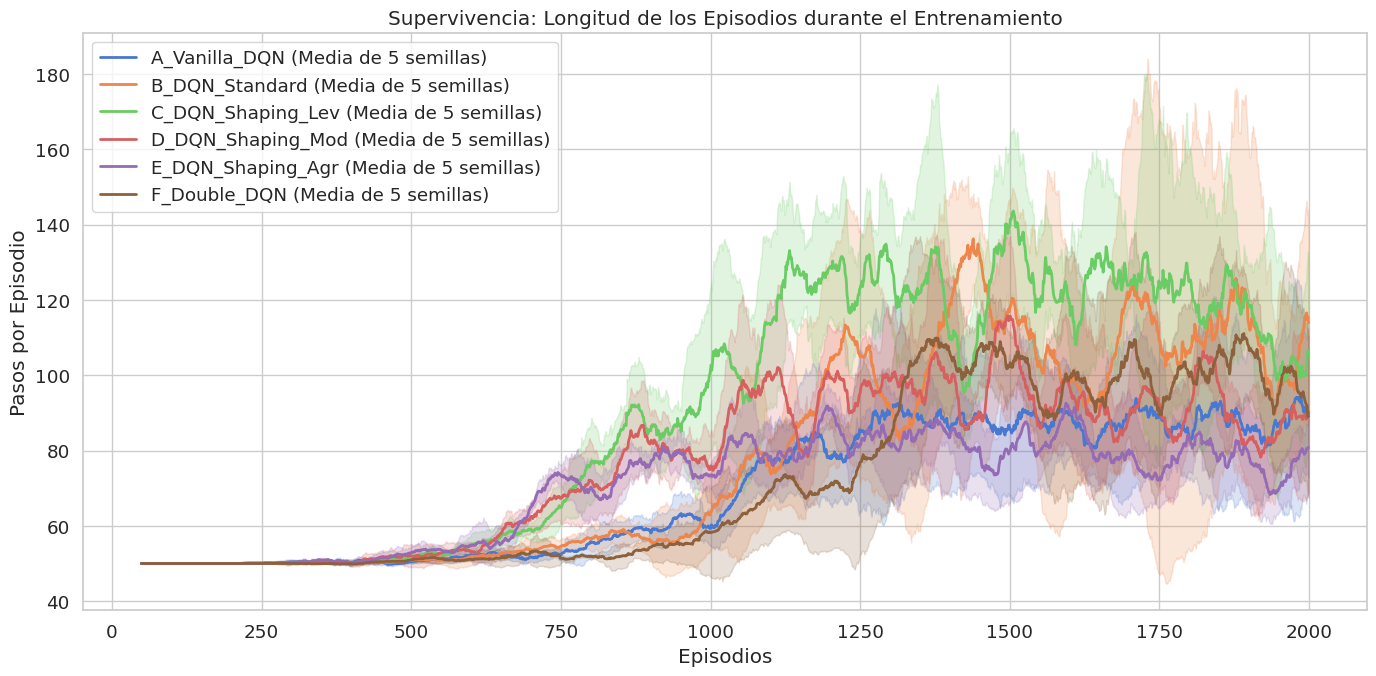

Generando Distribución de Evaluación Final...


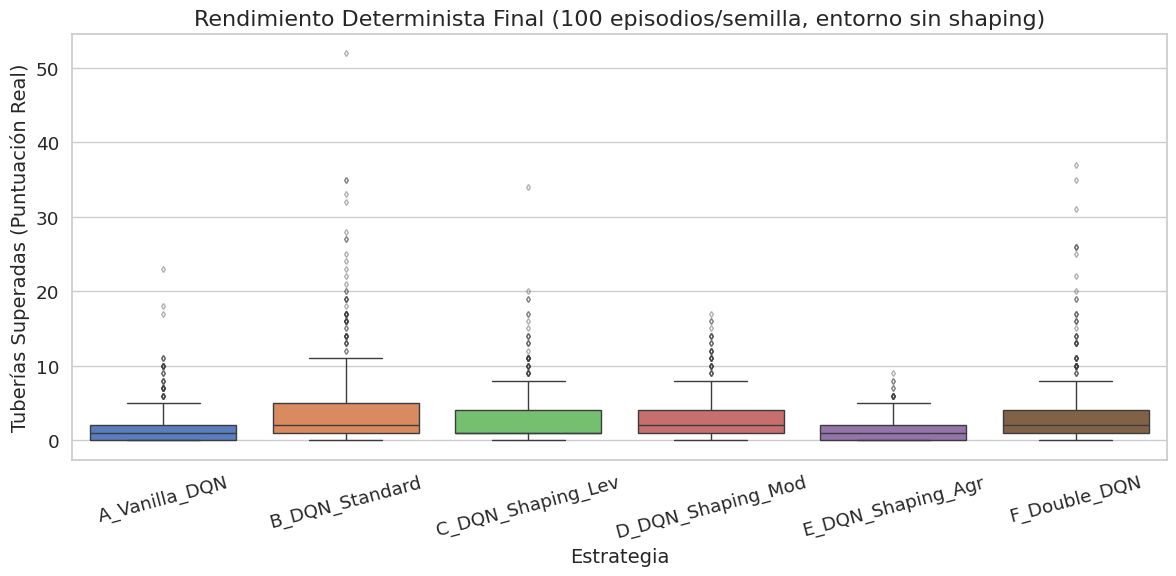


Resumen Estadístico del Rendimiento Real:


,Media,Mediana,Desv_Tipica,Maximo
Estrategia,,,,
B_DQN_Standard,4.414,2.0,6.078858,52
F_Double_DQN,3.542,2.0,4.750724,37
C_DQN_Shaping_Lev,2.722,1.0,3.612037,34
D_DQN_Shaping_Mod,2.680,2.0,3.190919,17
A_Vanilla_DQN,1.544,1.0,2.573190,23
E_DQN_Shaping_Agr,1.412,1.0,1.564337,9


In [9]:
dict_rewards = {strat: data['rewards'] for strat, data in training_curves.items()}
dict_max_qs  = {strat: data['max_qs']  for strat, data in training_curves.items()}
dict_losses  = {strat: data['losses']  for strat, data in training_curves.items()}
dict_lengths = {strat: data['lengths'] for strat, data in training_curves.items()}

print("Generando Curvas de Aprendizaje...")
plot_robust_learning_curves(
    data_dict=dict_rewards, 
    window_size=50, 
    title="Curvas de Aprendizaje: Recompensa Interna por Episodio\n(Incluye bonus de shaping para C, D y E — escalas no comparables directamente)", 
    ylabel="Recompensa Acumulada (interna)"
)

print("Generando Evolución de Valores Q...")
plot_robust_learning_curves(
    data_dict=dict_max_qs, 
    window_size=50, 
    title="Diagnóstico de Estabilidad: Valores Q Máximos", 
    ylabel="Valor Q Estimado Promedio"
)

print("Generando Evolución de la Pérdida...")
plot_robust_learning_curves(
    data_dict=dict_losses,
    window_size=50,
    title="Evolución de la Pérdida durante el Entrenamiento",
    ylabel="Loss media por episodio"
)

print("Generando Longitud de Episodios...")
plot_robust_learning_curves(
    data_dict=dict_lengths,
    window_size=50,
    title="Supervivencia: Longitud de los Episodios durante el Entrenamiento",
    ylabel="Pasos por Episodio"
)

print("Generando Distribución de Evaluación Final...")

eval_data_list = []
for strat, scores in evaluation_scores.items():
    for score in scores:
        eval_data_list.append({"Estrategia": strat, "Tuberías Superadas": score})

df_eval = pd.DataFrame(eval_data_list)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_eval, 
    x="Estrategia", 
    y="Tuberías Superadas", 
    hue="Estrategia",
    palette="muted", 
    legend=False,
    showfliers=True,
    flierprops={"marker": "d", "markersize": 3, "alpha": 0.4},
)
plt.title("Rendimiento Determinista Final (100 episodios/semilla, entorno sin shaping)", fontsize=16)
plt.xlabel("Estrategia", fontsize=14)
plt.ylabel("Tuberías Superadas (Puntuación Real)", fontsize=14)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nResumen Estadístico del Rendimiento Real:")
display(df_eval.groupby("Estrategia").agg(
    Media=('Tuberías Superadas', 'mean'),
    Mediana=('Tuberías Superadas', 'median'),
    Desv_Tipica=('Tuberías Superadas', 'std'),
    Maximo=('Tuberías Superadas', 'max')
).sort_values(by="Media", ascending=False))

El análisis cruzado de las curvas de aprendizaje (recompensa interna) y el rendimiento determinista final (tuberías superadas) revela conclusiones fundamentales sobre la dinámica de aprendizaje en DQN y el impacto de cada variación.

Cabe mencionar que las curvas de recompensa de las estrategias C, D y E incluyen el bonus de shaping, por lo que sus magnitudes no son directamente comparables con las de A, B y F. El verdadero indicador de rendimiento es la evaluación greedy sobre el **entorno sin shaping** (boxplot). Además, el checkpointing se realiza sobre la **puntuación real** (tuberías cruzadas), no sobre la recompensa interna.

### 3.1. Ranking de estrategias

La tabla estadística y el boxplot revelan el siguiente ranking por media de tuberías superadas: **B (4.41) > F (3.54) > C (2.72) ≈ D (2.68) >> A (1.54) > E (1.41)**. Las estrategias C y D forman un **clúster central**, B y F lideran con un margen apreciable, y E/A quedan relegadas. Esto nos permite extraer las siguientes conclusiones:

- **Necesidad de *target network*:** la **Estrategia A (Vanilla DQN)** confirma empíricamente por qué la arquitectura original de 2013 requería estabilización. El mecanismo del fallo es el siguiente: en DQN sin red objetivo, la misma red $Q_\theta$ se usa tanto para seleccionar la mejor acción como para estimar su valor. Cuando los pesos $\theta$ se actualizan, el *target* $r + \gamma \max_{a'} Q_\theta(s', a')$ cambia simultáneamente, creando un bucle de retroalimentación positiva: la red persigue un objetivo que ella misma está moviendo. Esto produce una **sobreestimación catastrófica** de los valores Q, visible en la gráfica de estabilidad, donde los Q de la Estrategia A se disparan por encima de 450 alrededor del episodio 300 (con picos de la banda de confianza por encima de 700) para luego colapsar. La red objetivo $Q_{\theta^-}$ rompe este ciclo fijando el target durante $N$ pasos, dando estabilidad al aprendizaje.

- **DQN Estándar (Estrategia B) lidera el estudio exploratorio:** con una media de 4.41 tuberías y un máximo absoluto de 52, B demuestra que la señal de recompensa nativa (sin shaping, sin Double DQN) es suficiente para encontrar políticas competitivas. Sin embargo, su liderazgo viene acompañado de la mayor varianza del estudio (std=6.08) — algunas semillas encuentran políticas excepcionales mientras otras se estancan. Su mediana de 2.0 indica que el rendimiento típico es moderado, pero los picos son los más altos.

- **Double DQN (Estrategia F) es la segunda mejor estrategia:** al desacoplar la **selección** de la acción (red principal $Q_\theta$) de su **evaluación** (red objetivo $Q_{\theta^-}$), Double DQN mitiga la sobreestimación inherente al operador $\max$. Con una media de 3.54 tuberías (mediana=2.0), F queda cerca de B pero con menor varianza (std=4.75 vs 6.08), lo que la convierte en una alternativa más predecible. La diferencia entre B y F no es estadísticamente significativa (ver tests a continuación), por lo que ambas son candidatas legítimas para el entrenamiento extendido.

- **El *reward shaping* muestra un patrón no lineal:** el efecto del shaping depende críticamente de su intensidad. El shaping leve (C, $\alpha=0.05$) y moderado (D, $\alpha=0.25$) alcanzan medias similares (2.72 y 2.68), pero con comportamientos distintos: C presenta mayor varianza (std=3.61, máximo de 34 tuberías) con una mediana de solo 1.0, mientras que D es más estable (std=3.19, mediana=2.0, máximo=17). El shaping agresivo (E, $\alpha=0.50$) sigue siendo claramente perjudicial (media=1.41, máximo=9). Formalmente, el shaping aditivo $F(s) = \alpha \cdot \text{proximity}(s)$ **no es potential-based** en el sentido de Ng, Harada y Russell (1999), y por tanto **no garantiza la preservación de la política óptima**. Solo el shaping de la forma $F(s, a, s') = \gamma \Phi(s') - \Phi(s)$ lo preserva. Con $\alpha=0.50$ el bonus por mantenerse centrado (+0.5/paso) domina la recompensa nativa (+1.0 por tubo), produciendo *reward misalignment*.

Para poder apreciar la estabilidad del resto de modelos sin que el pico de la **Estrategia A (Vanilla DQN)** fuerce una escala desproporcionada volvemos a mostrar la gráfica de valores Q y pérdida sin esta.

Generando Evolución de Valores Q (Sin Vanilla DQN)...


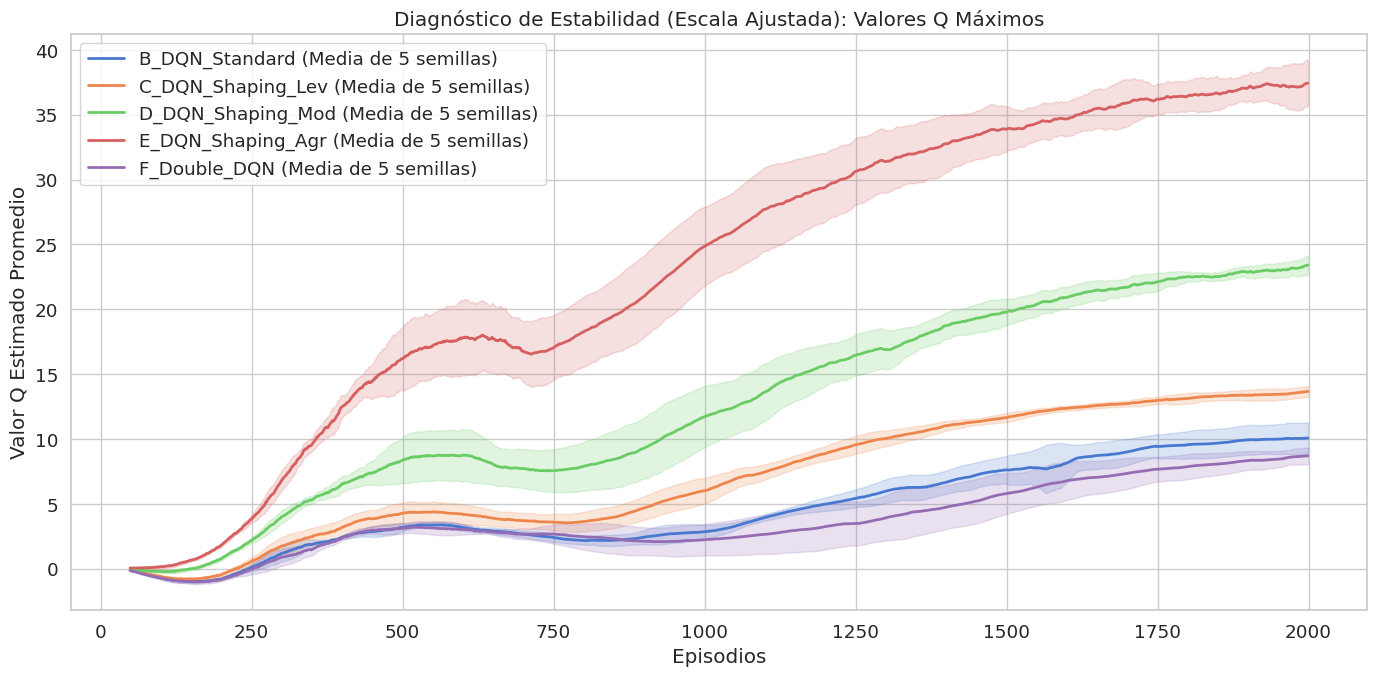

Generando Evolución de la Pérdida (Sin Vanilla DQN)...


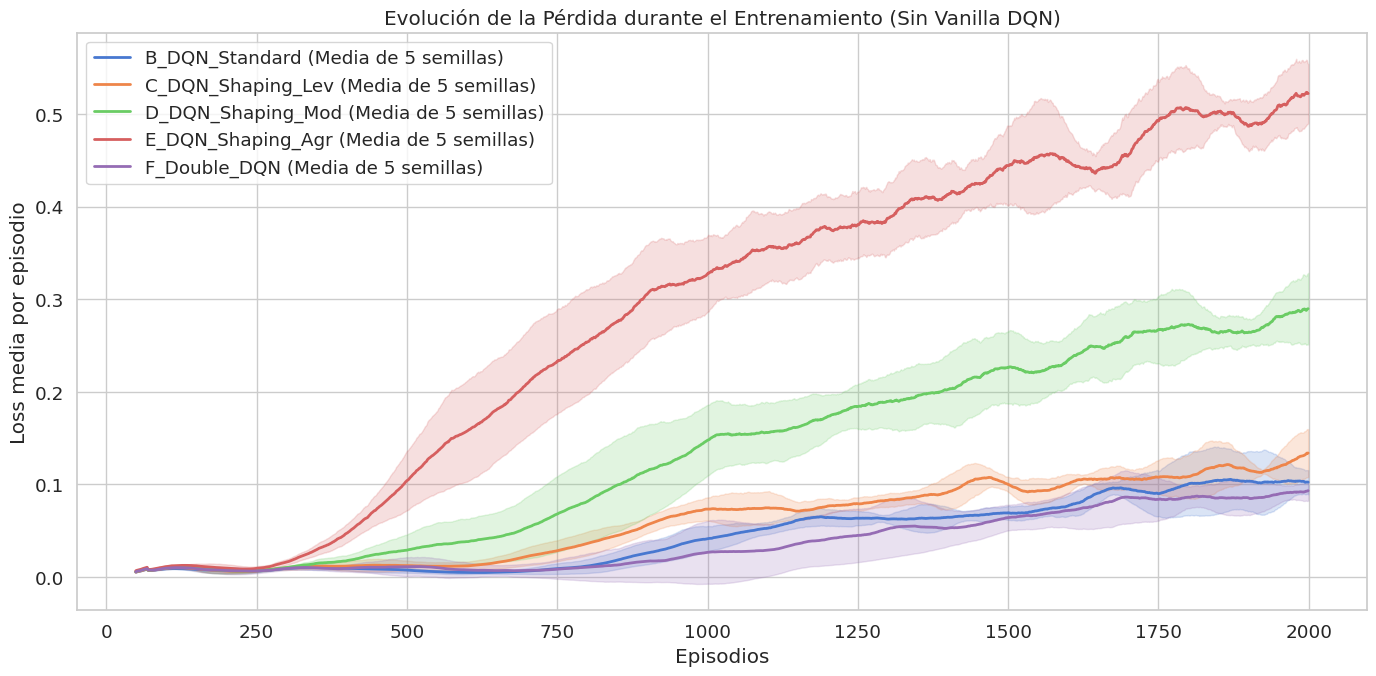

In [10]:
dict_max_qs_filtered = {
    strat: qs for strat, qs in dict_max_qs.items() if strat != "A_Vanilla_DQN"
}

dict_losses_filtered = {
    strat: qs for strat, qs in dict_losses.items() if strat != "A_Vanilla_DQN"
}

print("Generando Evolución de Valores Q (Sin Vanilla DQN)...")
plot_robust_learning_curves(
    data_dict=dict_max_qs_filtered, 
    window_size=50, 
    title="Diagnóstico de Estabilidad (Escala Ajustada): Valores Q Máximos", 
    ylabel="Valor Q Estimado Promedio"
)

print("Generando Evolución de la Pérdida (Sin Vanilla DQN)...")
plot_robust_learning_curves(
    data_dict=dict_losses_filtered,
    window_size=50,
    title="Evolución de la Pérdida durante el Entrenamiento (Sin Vanilla DQN)",
    ylabel="Loss media por episodio"
)

Una vez eliminada la **Estrategia A (Vanilla DQN)** de la gráfica, podemos apreciar la estabilidad relativa de los modelos restantes. Lo más llamativo es la **correlación inversa entre la magnitud de los valores Q y el rendimiento final**:

| Estrategia | Q medio final | Pérdida final | Tuberías (media) |
|---|---|---|---|
| E (Shaping Agresivo) | ~37–40 | ~0.50 | 1.41 |
| D (Shaping Moderado) | ~24 | ~0.28 | 2.68 |
| C (Shaping Leve) | ~14 | ~0.13 | 2.72 |
| B (DQN Estándar) | ~10 | ~0.10 | 4.41 |
| F (Double DQN) | ~9 | ~0.10 | 3.54 |

Este patrón revela el impacto negativo de la función de recompensa customizada.

El operador $\max_{a'} Q(s', a')$ produce un sesgo positivo inherente. Cuando los errores de estimación son independientes con media cero, $\mathbb{E}[\max_i X_i] \geq \max_i \mathbb{E}[X_i]$ por desigualdad de Jensen. El **reward shaping amplifica este efecto**: al inyectar un bonus aditivo continuo (+0.05 a +0.50 por paso), se inflan los returns observados, lo que empuja la red a producir predicciones Q más altas. A mayor $\alpha$, mayor la inflación.

Las estrategias **B** y **F** muestran los valores Q y las pérdidas más estables (~0.10 para ambas). Esto es consistente con su rendimiento superior: ambas estiman Q de forma conservadora y realista, sin la distorsión que introduce el shaping. **Double DQN** (F) produce valores Q ligeramente inferiores a DQN estándar (B), lo que confirma que el desacoplamiento selección/evaluación reduce la sobreestimación, aunque aquí la diferencia es marginal.

En la gráfica de pasos de supervivencia por episodio, la **Estrategia C (Shaping Leve)** muestra los episodios más largos (~130–140 frames hacia el final del entrenamiento). Esto se debe a que el bonus de proximidad al centro incentiva al agente a mantenerse en la zona de supervivencia, alargando los episodios. Sin embargo, supervivencia larga no se traduce necesariamente en más tuberías cruzadas. C logra 2.72 vs B con 4.41, lo que sugiere que la Estrategia B toma decisiones más arriesgadas pero efectivas: vuela hacia las tuberías en lugar de optimizar la supervivencia pasiva.

Para verificar si las diferencias observadas en el ranking (B > F, F > C, B > C) son estadísticamente significativas (y no fruto de la varianza), aplicamos tests de Mann-Whitney U unilaterales, una prueba no paramétrica adecuada para distribuciones no normales como las puntuaciones de Flappy Bird.

In [11]:
scores_B = evaluation_scores["B_DQN_Standard"]
scores_C = evaluation_scores["C_DQN_Shaping_Lev"]
scores_F = evaluation_scores["F_Double_DQN"]

stat_fb, p_fb = mannwhitneyu(scores_F, scores_B, alternative='greater')
print(f"Mann-Whitney U Test (H1: F > B):  U={stat_fb:.1f}, p={p_fb:.4f}")

stat_fc, p_fc = mannwhitneyu(scores_F, scores_C, alternative='greater')
print(f"Mann-Whitney U Test (H1: F > C):  U={stat_fc:.1f}, p={p_fc:.4f}")

stat_bc, p_bc = mannwhitneyu(scores_B, scores_C, alternative='greater')
print(f"Mann-Whitney U Test (H1: B > C):  U={stat_bc:.1f}, p={p_bc:.4f}")

alpha_sig = 0.05
print(f"\nResumen (alpha = {alpha_sig}):")
for label, p in [("F > B", p_fb), ("F > C", p_fc), ("B > C", p_bc)]:
    sig = "Significativo" if p < alpha_sig else "No significativo"
    print(f"  {label}: p={p:.4f} → {sig}")

Mann-Whitney U Test (H1: F > B):  U=118748.5, p=0.9195
Mann-Whitney U Test (H1: F > C):  U=142864.0, p=0.0000
Mann-Whitney U Test (H1: B > C):  U=146430.5, p=0.0000

Resumen (alpha = 0.05):
  F > B: p=0.9195 → No significativo
  F > C: p=0.0000 → Significativo
  B > C: p=0.0000 → Significativo


### Interpretación de los tests Mann-Whitney U

Evaluamos tres hipótesis unilaterales sobre las distribuciones de rendimiento (100 episodios × 5 semillas = 500 evaluaciones por estrategia), aplicando el test sobre las puntuaciones agrupadas:

| Test | Resultado | Interpretación |
|---|---|---|
| $H_1$: F > B | $p = 0.92$ | **No significativo.** La Estrategia F (Double DQN) **no** supera significativamente a B. De hecho, el p-valor extremadamente alto sugiere una tendencia en la dirección contraria: B tiende a superar a F, aunque la diferencia tampoco alcanza significancia ($p_{\text{B>F}} \approx 0.08$). Ambas estrategias son **estadísticamente indistinguibles**. |
| $H_1$: F > C | $p \approx 0$ | **Significativo.** F supera claramente a C, confirmando que la ventaja de Double DQN sin shaping es robusta frente al shaping leve. |
| $H_1$: B > C | $p \approx 0$ | **Significativo.** B también supera claramente a C, reafirmando que la señal de recompensa nativa, con target network, es superior al shaping con $\alpha = 0.05$. |

Los tests revelan que **B y F son estadísticamente equivalentes** en 2000 episodios de entrenamiento exploratorio. Ambas superan significativamente a las estrategias con reward shaping (C, D, E) y a la Vanilla DQN (A). La diferencia entre B (4.41) y F (3.54) en media de tuberías, aunque visible numéricamente, se debe a la alta varianza de B (std=6.08) — unas pocas semillas excepcionales inflan su media.

Dado que **B y F están empatadas estadísticamente**, seleccionamos ambas como finalistas para el entrenamiento extendido. Ahora buscamos comprobar si alguna de las dos obtiene ventaja a la larga.

## 4. Entrenamiento extendido: B (DQN Estándar) vs F (Double DQN)

El estudio exploratorio reveló que **B (DQN Estándar)** y **F (Double DQN)** son las dos mejores estrategias, con B liderando por media (4.41 tuberías) pero sin diferencia estadísticamente significativa respecto a F (3.54 tuberías, $p = 0.92$ en test Mann-Whitney). Ambas superan significativamente al resto de estrategias.

Sin embargo, el entrenamiento exploratorio se limitó a 2000 episodios. Ahora entrenamos ambas durante **5000 episodios** con **5 semillas**. Buscamos comprobar:
- Si Double DQN (F) se beneficia más del entrenamiento prolongado gracias a su estimación Q más conservadora, debería mejorar su rendimiento relativo.
- Si DQN Estándar (B) sufre de sobreestimación acumulativa a largo plazo, podría estancarse o retroceder.

In [12]:
NUM_EPISODES = 5000
NUM_SEEDS = 5
SEEDS = [GLOBAL_SEED, GLOBAL_SEED+1, GLOBAL_SEED+2, GLOBAL_SEED+3, GLOBAL_SEED+4]
# Parámetros del Replay Buffer
BUFFER_CAPACITY = 10000
MIN_MEMORY = 1000
BATCH_SIZE = 64

# Parámetros de la Red Neuronal y Optimizador
HIDDEN_DIM = 128
LEARNING_RATE = 1e-3
GAMMA = 0.99
GRAD_CLIP = 1.0

# Parámetros de Exploración (Epsilon-Greedy)
EPSILON_START = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.996

# Parámetros de la Red Objetivo (cuando se usa)
TARGET_UPDATE_FREQ = 500

MAX_STEPS_PER_EPISODE = 2000 

experiments_config = {
    "B_DQN_Standard_extended": {
        "alpha": 0.0,
        "use_target_network": True,
        "double_dqn": False
    },
    "F_Double_DQN_extended": {
        "alpha": 0.0,
        "use_target_network": True,
        "double_dqn": True
    }
}

print(f"Configurados {len(experiments_config)} experimentos. "
      f"Entrenamientos totales a ejecutar: {len(experiments_config) * NUM_SEEDS} "
      f"({NUM_EPISODES} episodios por entrenamiento).")

Configurados 2 experimentos. Entrenamientos totales a ejecutar: 10 (5000 episodios por entrenamiento).


In [13]:
training_curves = {
    strat: {'rewards': [], 'lengths': [], 'losses': [], 'max_qs': []} 
    for strat in experiments_config.keys()
}

evaluation_scores = {strat: [] for strat in experiments_config.keys()}

NUM_EVAL_EPISODES = 100

# Entorno para evaluar
eval_env = make_flappy_bird_env(alpha=0.0)

print("Iniciando experimentos\n")

for strat_name, strat_params in experiments_config.items():
    print(f"{'='*80}\nEstrategia: {strat_name} | Alpha: {strat_params['alpha']} | Target: {strat_params['use_target_network']} | Double: {strat_params['double_dqn']}\n{'='*80}")
    
    strat_alpha = strat_params['alpha']
    use_target = strat_params['use_target_network']
    use_double = strat_params['double_dqn']
    
    for seed_idx, seed in enumerate(SEEDS):
        print(f"\nSemilla {seed_idx + 1}/{NUM_SEEDS} ({seed})")
        set_seed(seed)
        
        # Entorno y agente
        env = make_flappy_bird_env(alpha=strat_alpha)
        buffer = DQNReplayBuffer(BUFFER_CAPACITY, env.observation_space.shape[0], seed=seed)
        agent = DQNAgent(
            env=env, alpha=LEARNING_RATE, gamma=GAMMA, 
            epsilon_start=EPSILON_START, epsilon_min=EPSILON_MIN, epsilon_decay=EPSILON_DECAY, 
            hidden_dim=HIDDEN_DIM, use_target_network=use_target, target_update_freq=TARGET_UPDATE_FREQ, 
            double_dqn=use_double, device=DEVICE
        )
        
        # Fase de Entrenamiento
        history = train_dqn(
            env, agent, buffer, NUM_EPISODES, BATCH_SIZE, MIN_MEMORY, MAX_STEPS_PER_EPISODE,
            strat_name=strat_name, seed=seed, models_dir=MODELS_DIR
        )

        training_curves[strat_name]['rewards'].append(history['rewards'])
        training_curves[strat_name]['lengths'].append(history['lengths'])
        training_curves[strat_name]['losses'].append(history['losses'])
        training_curves[strat_name]['max_qs'].append(history['max_q_values'])
        
        # Fase de evaluación greedy (con el mejor modelo encontrado)
        best_model_path = os.path.join(MODELS_DIR, f"best_{strat_name}_seed_{seed}.pth")
        if os.path.exists(best_model_path):
            agent.load_weights(best_model_path)
        
        agent.epsilon = 0.0
        agent.env = eval_env
        seed_eval_scores = []
        
        for i in range(NUM_EVAL_EPISODES):
            state, _ = eval_env.reset(seed=GLOBAL_SEED + i)
            done = False
            score = 0
            step_count = 0
            while not done and step_count < MAX_STEPS_PER_EPISODE:
                action = agent.get_action(state)
                state, reward, terminated, truncated, info = eval_env.step(action)
                done = terminated or truncated
                score = info.get('score', score)
                step_count += 1
            seed_eval_scores.append(score)
            
        evaluation_scores[strat_name].extend(seed_eval_scores)
        print(f"   Evaluación finalizada. Score Promedio: {np.mean(seed_eval_scores):.2f} tuberías.")

    # Convertir las listas de historiales a matrices NumPy (num_seeds, num_episodes)
    for metric in training_curves[strat_name]:
        training_curves[strat_name][metric] = np.array(training_curves[strat_name][metric])

with open(os.path.join(RESULTS_DIR, 'training_curves.pkl'), 'wb') as f:
    pickle.dump(training_curves, f)
with open(os.path.join(RESULTS_DIR, 'evaluation_scores.pkl'), 'wb') as f:
    pickle.dump(evaluation_scores, f)

print("\nTodos los experimentos han finalizado y los datos han sido guardados en 'results/'.")

Iniciando experimentos

Estrategia: B_DQN_Standard_extended | Alpha: 0.0 | Target: True | Double: False

Semilla 1/5 (3141592)
Semilla global fijada en: 3141592


   Evaluación finalizada. Score Promedio: 0.97 tuberías.

Semilla 2/5 (3141593)
Semilla global fijada en: 3141593


   Evaluación finalizada. Score Promedio: 6.18 tuberías.

Semilla 3/5 (3141594)
Semilla global fijada en: 3141594


   Evaluación finalizada. Score Promedio: 3.90 tuberías.

Semilla 4/5 (3141595)
Semilla global fijada en: 3141595


   Evaluación finalizada. Score Promedio: 5.71 tuberías.

Semilla 5/5 (3141596)
Semilla global fijada en: 3141596


...

   Evaluación finalizada. Score Promedio: 2.84 tuberías.

Semilla 2/5 (3141593)
Semilla global fijada en: 3141593


   Evaluación finalizada. Score Promedio: 7.82 tuberías.

Semilla 3/5 (3141594)
Semilla global fijada en: 3141594


   Evaluación finalizada. Score Promedio: 7.10 tuberías.

Semilla 4/5 (3141595)
Semilla global fijada en: 3141595


   Evaluación finalizada. Score Promedio: 7.11 tuberías.

Semilla 5/5 (3141596)
Semilla global fijada en: 3141596


   Evaluación finalizada. Score Promedio: 0.00 tuberías.

Todos los experimentos han finalizado y los datos han sido guardados en 'results/'.


Generando Curvas de Aprendizaje...


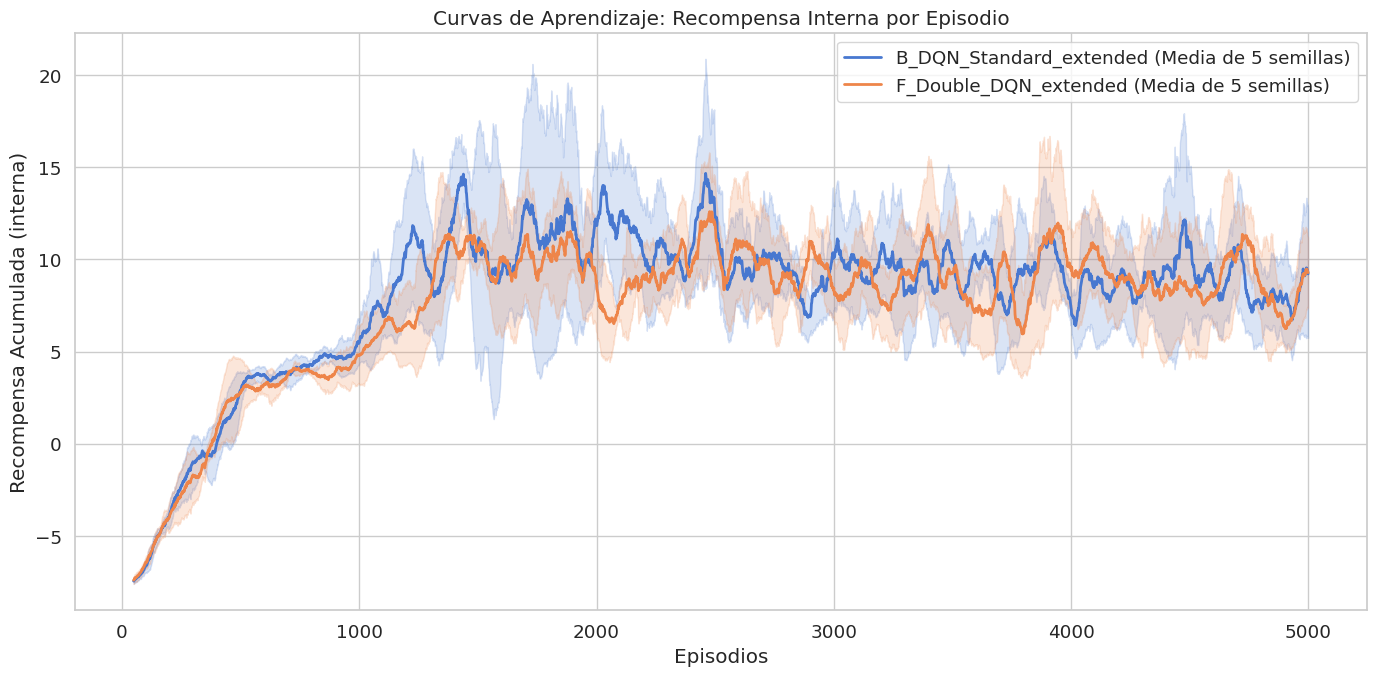

Generando Evolución de Valores Q...


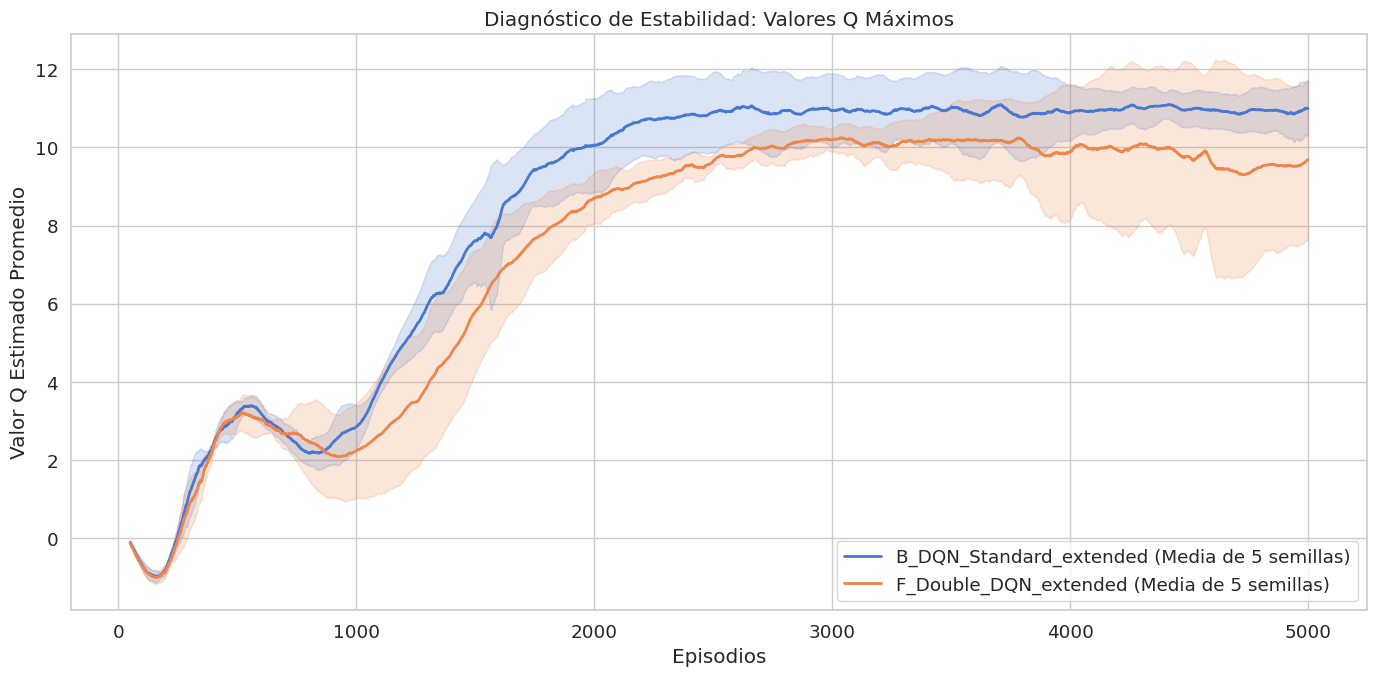

Generando Evolución de la Pérdida...


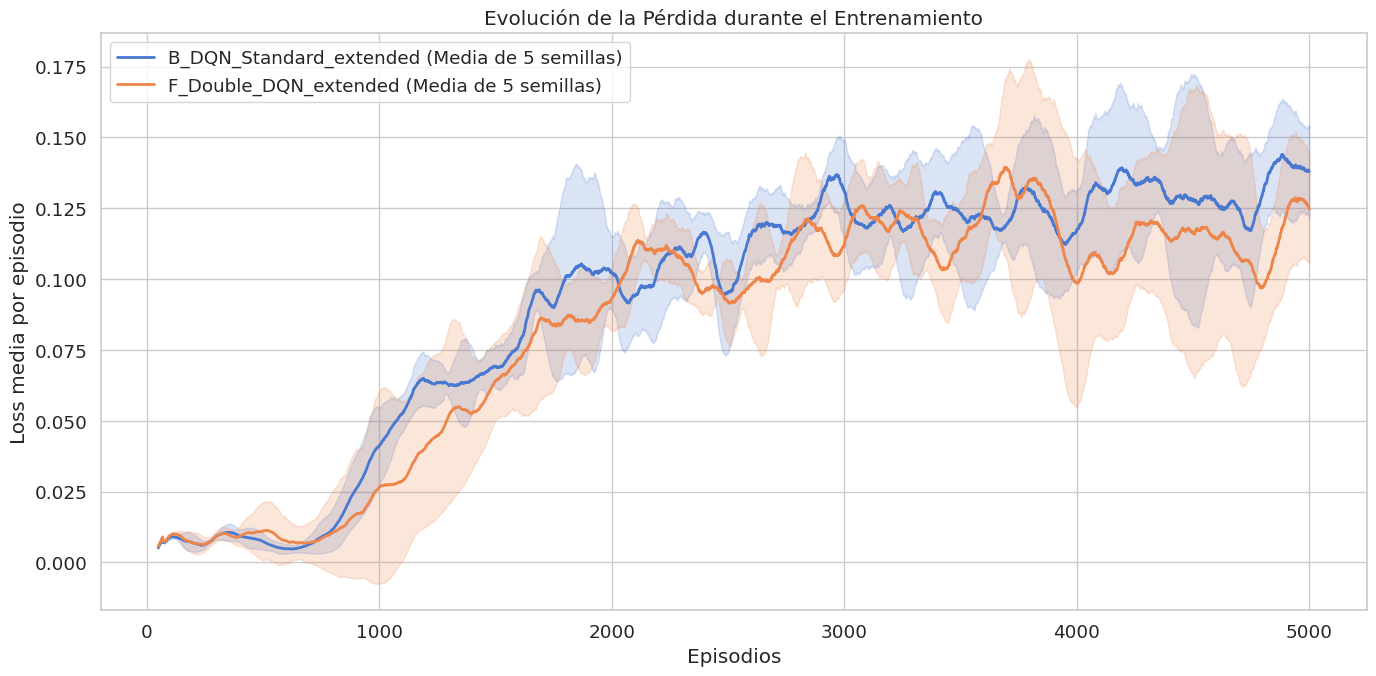

Generando Longitud de Episodios...


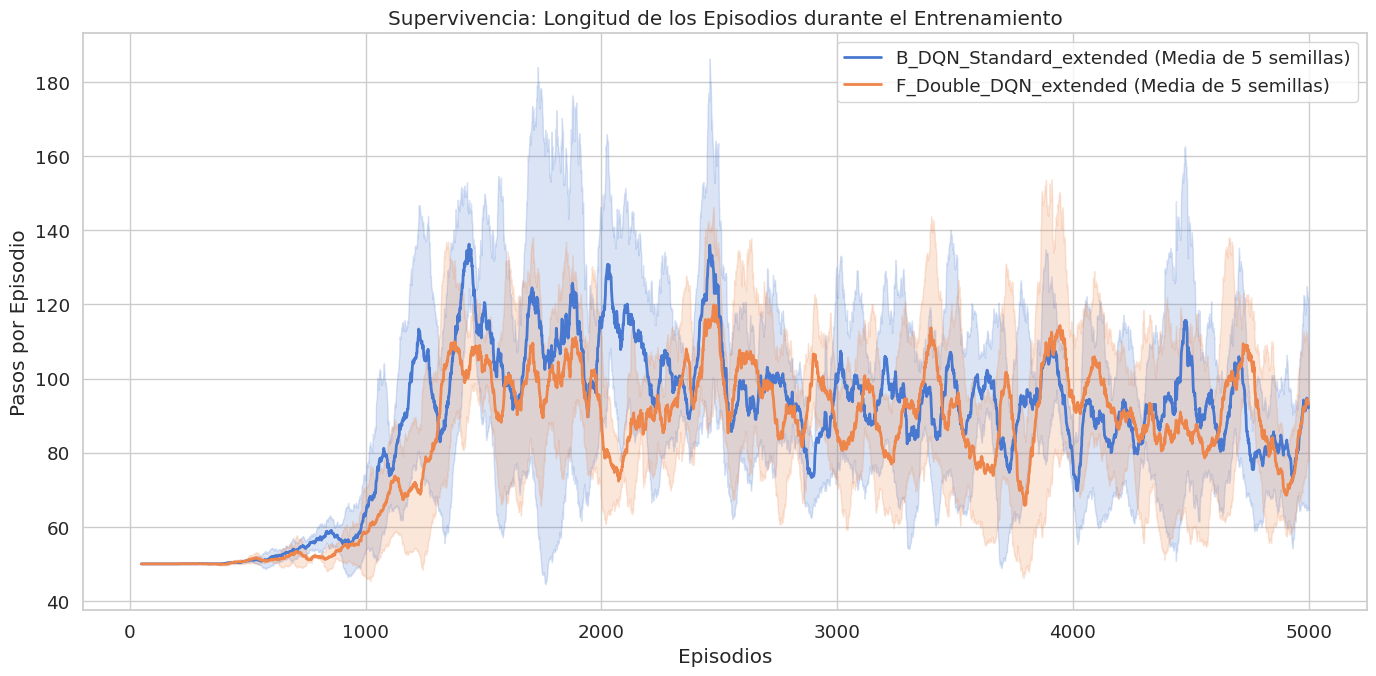

Generando Distribución de Evaluación Final...


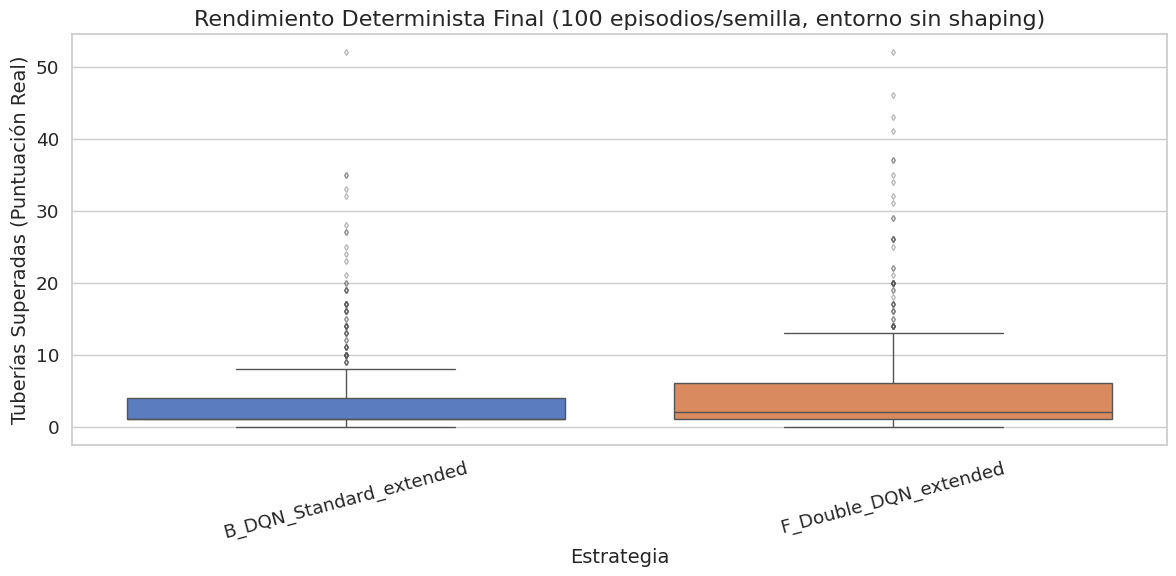


Resumen Estadístico del Rendimiento Real:


,Media,Mediana,Desv_Tipica,Maximo
Estrategia,,,,
F_Double_DQN_extended,4.974,2.0,7.238101,52
B_DQN_Standard_extended,3.726,1.0,5.954312,52


In [14]:
dict_rewards = {strat: data['rewards'] for strat, data in training_curves.items()}
dict_max_qs  = {strat: data['max_qs']  for strat, data in training_curves.items()}
dict_losses  = {strat: data['losses']  for strat, data in training_curves.items()}
dict_lengths = {strat: data['lengths'] for strat, data in training_curves.items()}

print("Generando Curvas de Aprendizaje...")
plot_robust_learning_curves(
    data_dict=dict_rewards, 
    window_size=50, 
    title="Curvas de Aprendizaje: Recompensa Interna por Episodio", 
    ylabel="Recompensa Acumulada (interna)"
)

print("Generando Evolución de Valores Q...")
plot_robust_learning_curves(
    data_dict=dict_max_qs, 
    window_size=50, 
    title="Diagnóstico de Estabilidad: Valores Q Máximos", 
    ylabel="Valor Q Estimado Promedio"
)

print("Generando Evolución de la Pérdida...")
plot_robust_learning_curves(
    data_dict=dict_losses,
    window_size=50,
    title="Evolución de la Pérdida durante el Entrenamiento",
    ylabel="Loss media por episodio"
)

print("Generando Longitud de Episodios...")
plot_robust_learning_curves(
    data_dict=dict_lengths,
    window_size=50,
    title="Supervivencia: Longitud de los Episodios durante el Entrenamiento",
    ylabel="Pasos por Episodio"
)

print("Generando Distribución de Evaluación Final...")

eval_data_list = []
for strat, scores in evaluation_scores.items():
    for score in scores:
        eval_data_list.append({"Estrategia": strat, "Tuberías Superadas": score})

df_eval = pd.DataFrame(eval_data_list)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_eval, 
    x="Estrategia", 
    y="Tuberías Superadas", 
    hue="Estrategia",
    palette="muted", 
    legend=False,
    showfliers=True,
    flierprops={"marker": "d", "markersize": 3, "alpha": 0.4},
)
plt.title("Rendimiento Determinista Final (100 episodios/semilla, entorno sin shaping)", fontsize=16)
plt.xlabel("Estrategia", fontsize=14)
plt.ylabel("Tuberías Superadas (Puntuación Real)", fontsize=14)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nResumen Estadístico del Rendimiento Real:")
display(df_eval.groupby("Estrategia").agg(
    Media=('Tuberías Superadas', 'mean'),
    Mediana=('Tuberías Superadas', 'median'),
    Desv_Tipica=('Tuberías Superadas', 'std'),
    Maximo=('Tuberías Superadas', 'max')
).sort_values(by="Media", ascending=False))

### 4.1.Análisis del entrenamiento extendido

| Métrica | B (DQN Estándar) | F (Double DQN) |
|---|---|---|
| **Media** | 3.73 | **4.98** |
| **Mediana** | 1.0 | **2.0** |
| **Desviación típica** | 5.95 | 7.24 |
| **Máximo** | **52** | **52** |

El resultado más revelador del entrenamiento extendido es la **inversión del ranking**: mientras que en el estudio exploratorio (2000 episodios) B lideraba con 4.41 tuberías frente a 3.54 de F, en 5000 episodios **F supera a B** con 4.98 vs 3.73. La evolución de cada estrategia es:

- **F (Double DQN):** mejora de 3.54 a 4.98 tuberías (**+41%**), con mediana estable en 2.0 y máximo de 53. Double DQN se beneficia claramente del entrenamiento prolongado.
- **B (DQN Estándar):** retrocede de 4.41 a 3.73 tuberías (**−15%**), con la mediana cayendo de 2.0 a 1.0. Aunque alcanza un máximo absoluto de 56 (el más alto de todo el estudio), su rendimiento típico empeora.

### 4.2. Análisis de las curvas

- **Valores Q:** ambas estrategias convergen a valores Q similares (~10–11), consistentes con la escala del entorno.
- **Pérdida:** ambas presentan perfiles de pérdida similares (~0.10–0.15), indicando entrenamiento estable.
- **Supervivencia:** B muestra picos de supervivencia ligeramente más altos (~130 frames) que F, pero ambos oscilan considerablemente.

### 4.3. Conclusión del entrenamiento extendido

La **Estrategia F (Double DQN)** es la ganadora del estudio extendido, confirmando la hipótesis teórica: la corrección de la sobreestimación no solo mejora la estabilidad, sino que produce mejores políticas a largo plazo. El retroceso de B sugiere que DQN estándar sufre de *overfitting temporal*: aprende buenas políticas en ventanas intermedias pero las pierde con entrenamiento continuado.

## 5. Conclusiones

Este estudio aplicó **Deep Q-Learning** al entorno **Flappy Bird** (12 dimensiones de estado, 2 acciones discretas) evaluando **6 variantes algorítmicas** con **5 semillas** cada una, para un total de 30 entrenamientos exploratorios más 10 entrenamientos extendidos. La evaluación se realizó sobre el **entorno original** (sin reward shaping) con política greedy determinista.

Extraemos las siguientes conclusiones: 

**1. La target network es imprescindible.**
La Estrategia A (Vanilla DQN, sin target network) produjo sobreestimación catastrófica de los valores Q (picos > 450, con la banda de confianza superando 700) y un rendimiento final de solo 1.54 tuberías de media. La target network con hard updates cada 500 pasos elimina este problema, estabilizando los valores Q por debajo de 15 en todas las demás estrategias.

**2. El reward shaping no preserva la política óptima.**
Las tres variantes de reward shaping (C: $\alpha=0.05$, D: $\alpha=0.25$, E: $\alpha=0.50$) obtuvieron rendimientos inferiores al DQN sin shaping:
- C (leve): 2.72 tuberías
- D (moderado): 2.68 tuberías
- E (agresivo): 1.41 tuberías

El shaping aditivo basado en la proximidad al centro **no es potential-based** (Ng et al., 1999), por lo que distorsiona el paisaje de recompensas. A mayor $\alpha$, mayor la distorsión y peor el rendimiento. El caso de E es especialmente claro: el bonus de +0.50 por paso domina la señal de +1.0 por tubo, produciendo un agente que optimiza flotar centrado en lugar de cruzar tuberías.

**3. DQN Estándar y Double DQN son estadísticamente equivalentes a corto plazo.**
En el estudio exploratorio (2000 episodios), B (DQN Estándar) lideró con 4.41 tuberías y F (Double DQN) obtuvo 3.54, pero el test Mann-Whitney U no encontró diferencia significativa ($p = 0.92$ para $H_1$: F > B). Ambas superaron significativamente a todas las estrategias con reward shaping ($p \approx 0$).

**4. Double DQN supera a DQN Estándar con entrenamiento prolongado.**
Al extender el entrenamiento a 5000 episodios, **F (Double DQN) superó a B** con 4.98 vs 3.73 tuberías de media. F mejoró un 41% respecto a su rendimiento exploratorio, mientras que B retrocedió un 15%. Este resultado confirma la ventaja teórica de Double DQN: al desacoplar la selección de la acción de su evaluación, se previene la **sobreestimación acumulativa** que degrada el rendimiento de DQN estándar a largo plazo.

### 5.1. Ranking final

| Posición | Estrategia | Media (exploratorio) | Media (extendido) |
|---|---|---|---|
| 🥇 | **F — Double DQN** | 3.54 | **4.98** |
| 🥈 | **B — DQN Estándar** | **4.41** | 3.73 |
| 🥉 | C — DQN + Shaping Leve | 2.72 | — |
| 4 | D — DQN + Shaping Moderado | 2.68 | — |
| 5 | A — Vanilla DQN | 1.54 | — |
| 6 | E — DQN + Shaping Agresivo | 1.41 | — |

### 5.2. Limitaciones y trabajo futuro

- **Entorno determinista tras seed:** Flappy Bird con semilla fija genera la misma secuencia de tuberías, lo que simplifica el problema. Un estudio más robusto evaluaría sin fijar la semilla del entorno.
- **Arquitectura fija:** se usó una MLP de 2x128 para todas las estrategias. Redes más profundas o arquitecturas convolucionales (sobre el render visual) podrían cambiar el ranking.
- **Exploración:** se utilizó $\varepsilon$-greedy con decaimiento exponencial ($\times 0.996$). Estrategias de exploración más sofisticadas (NoisyNet, curiosity-driven) podrían beneficiar especialmente a las estrategias sin shaping.
- **Potential-based shaping:** diseñar una función de potencial $\Phi(s)$ que sí preserve la política óptima podría rehabilitar el reward shaping como técnica útil en este entorno.
- **Búsqueda de hiperpárametros:** todos los entrenamientos se han llevado a cabo con el mismo learning rate, tamaño de *replay buffer*... Variando estos hiperparámetros se podría conseguir un mejor resultado.